In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load the Iris dataset from seaborn
iris = sns.load_dataset('iris')

# Display basic information about the dataset
print("=" * 50)
print("IRIS DATASET EXPLORATION")
print("=" * 50)

# 1. Shape of the dataset
print(f"\n1. DATASET SHAPE: {iris.shape}")
print(f"   - Rows (samples): {iris.shape[0]}")
print(f"   - Columns (features): {iris.shape[1]}")

# 2. Column names
print(f"\n2. COLUMN NAMES:")
print(f"   {list(iris.columns)}")

# 3. First few rows
print(f"\n3. FIRST 5 ROWS:")
print(iris.head())

# 4. Dataset info
print(f"\n4. DATASET INFO:")
iris.info()

# 5. Descriptive statistics
print(f"\n5. DESCRIPTIVE STATISTICS:")
print(iris.describe())

IRIS DATASET EXPLORATION

1. DATASET SHAPE: (150, 5)
   - Rows (samples): 150
   - Columns (features): 5

2. COLUMN NAMES:
   ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

3. FIRST 5 ROWS:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

4. DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species      

In [3]:
# Additional exploration
print("\n6. SPECIES DISTRIBUTION:")
print(iris['species'].value_counts())

print("\n7. MISSING VALUES:")
print(iris.isnull().sum())


6. SPECIES DISTRIBUTION:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

7. MISSING VALUES:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64



Creating scatter plot matrix...


<Figure size 1400x1000 with 0 Axes>

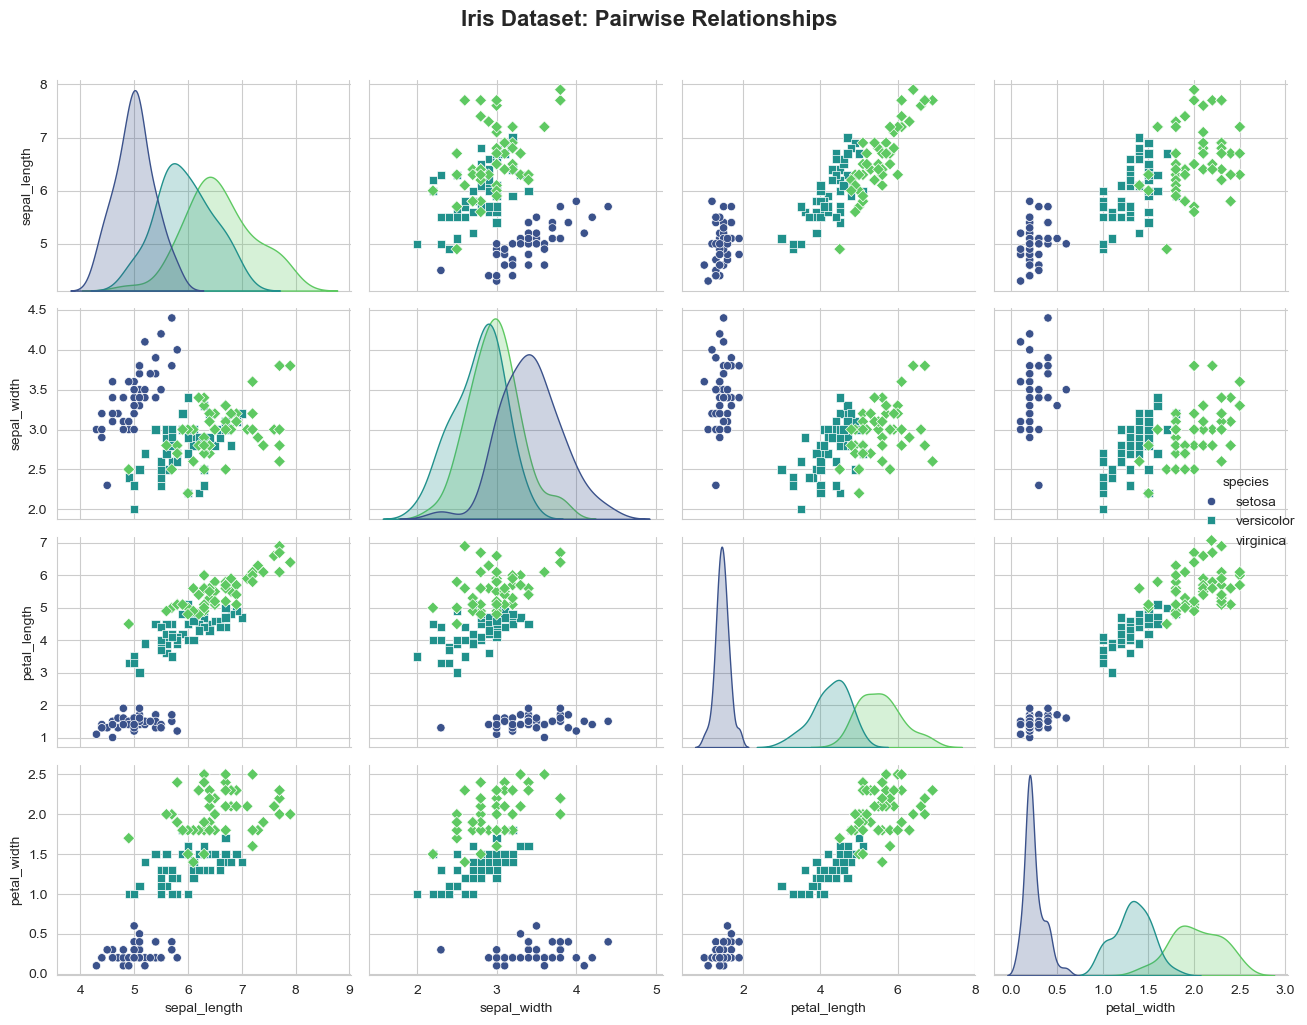

✓ Pairplot saved!


In [4]:
import os
os.makedirs('output', exist_ok=True)

# VISUALIZATION 1: Scatter Plot Matrix (Pairplot)
print("\nCreating scatter plot matrix...")
fig1 = plt.figure(figsize=(14, 10))
pair_plot = sns.pairplot(iris, hue='species', palette='viridis', 
                         diag_kind='kde', markers=['o', 's', 'D'],
                         height=2.5, aspect=1.2)
pair_plot.fig.suptitle('Iris Dataset: Pairwise Relationships', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('output/iris_pairplot.png', dpi=150, bbox_inches='tight')

plt.show()
print("✓ Pairplot saved!")

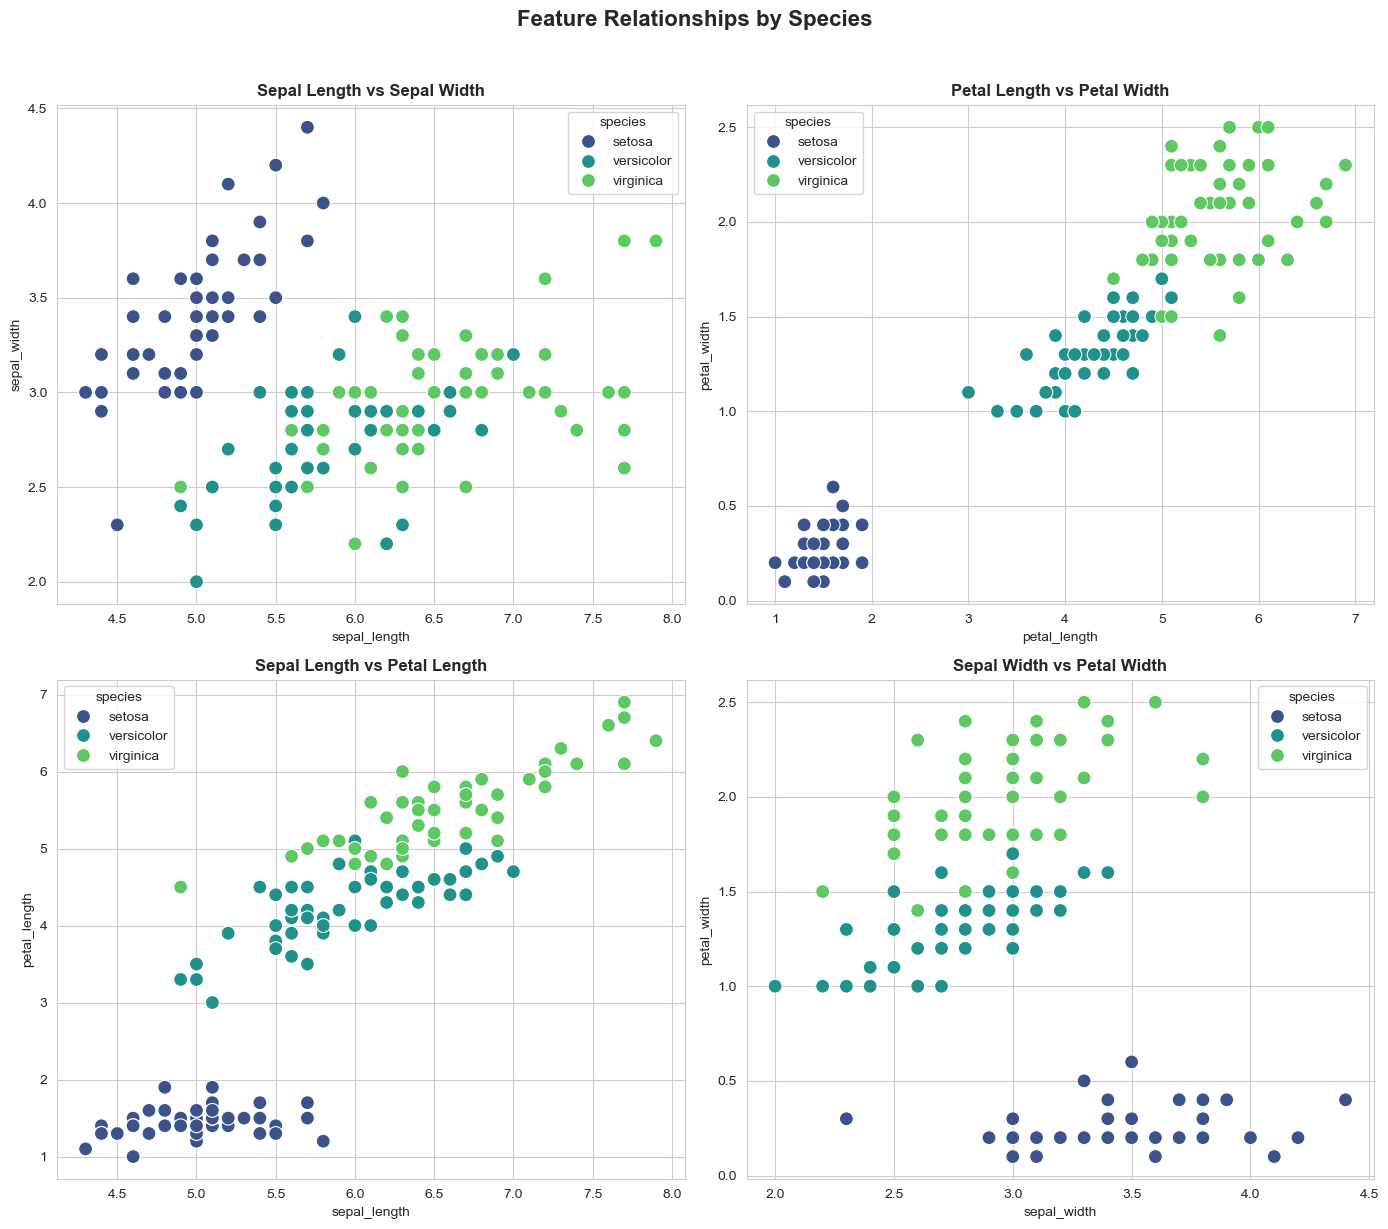

✓ Scatter plots saved!


In [5]:
# VISUALIZATION 2: Individual Scatter Plots (Sepal vs Petal)
fig2, axes = plt.subplots(2, 2, figsize=(14, 12))

# Sepal length vs Sepal width
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', 
                hue='species', palette='viridis', s=100, ax=axes[0,0])
axes[0,0].set_title('Sepal Length vs Sepal Width', fontsize=12, fontweight='bold')

# Petal length vs Petal width
sns.scatterplot(data=iris, x='petal_length', y='petal_width', 
                hue='species', palette='viridis', s=100, ax=axes[0,1])
axes[0,1].set_title('Petal Length vs Petal Width', fontsize=12, fontweight='bold')

# Sepal length vs Petal length
sns.scatterplot(data=iris, x='sepal_length', y='petal_length', 
                hue='species', palette='viridis', s=100, ax=axes[1,0])
axes[1,0].set_title('Sepal Length vs Petal Length', fontsize=12, fontweight='bold')

# Sepal width vs Petal width
sns.scatterplot(data=iris, x='sepal_width', y='petal_width', 
                hue='species', palette='viridis', s=100, ax=axes[1,1])
axes[1,1].set_title('Sepal Width vs Petal Width', fontsize=12, fontweight='bold')

plt.suptitle('Feature Relationships by Species', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/iris_scatterplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Scatter plots saved!")

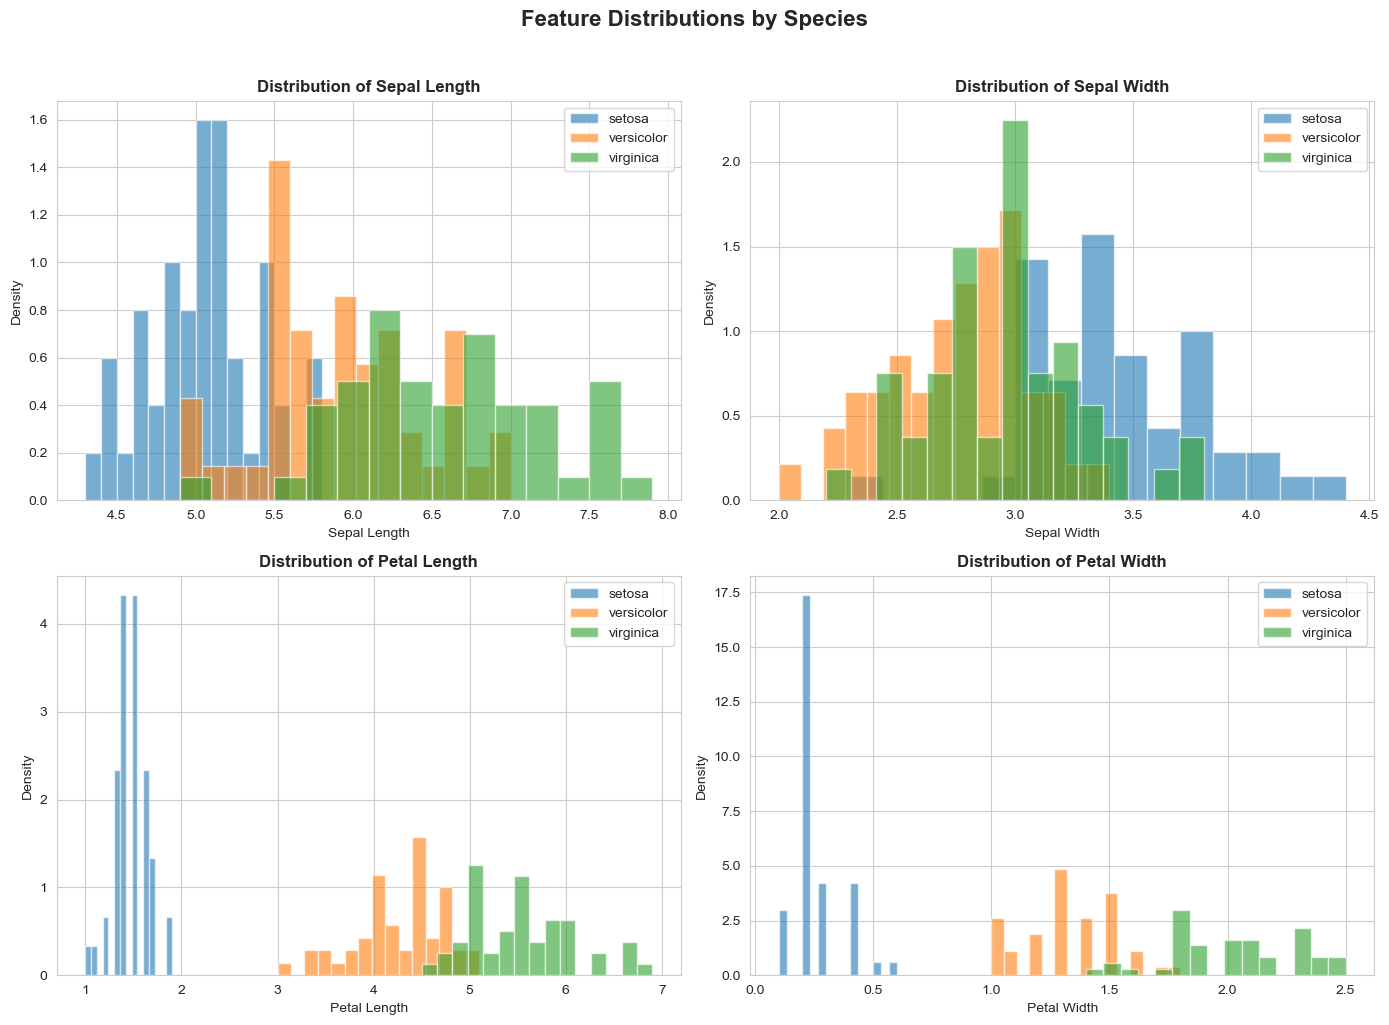

✓ Histograms saved!


In [6]:
# VISUALIZATION 3: Histograms
fig3, axes = plt.subplots(2, 2, figsize=(14, 10))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (feature, color) in enumerate(zip(features, colors)):
    ax = axes[idx//2, idx%2]
    
    # Create histogram with KDE
    for species in iris['species'].unique():
        subset = iris[iris['species'] == species][feature]
        ax.hist(subset, alpha=0.6, bins=15, label=species, density=True)
    
    ax.set_title(f'Distribution of {feature.replace("_", " ").title()}', fontweight='bold')
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Feature Distributions by Species', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/iris_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Histograms saved!")

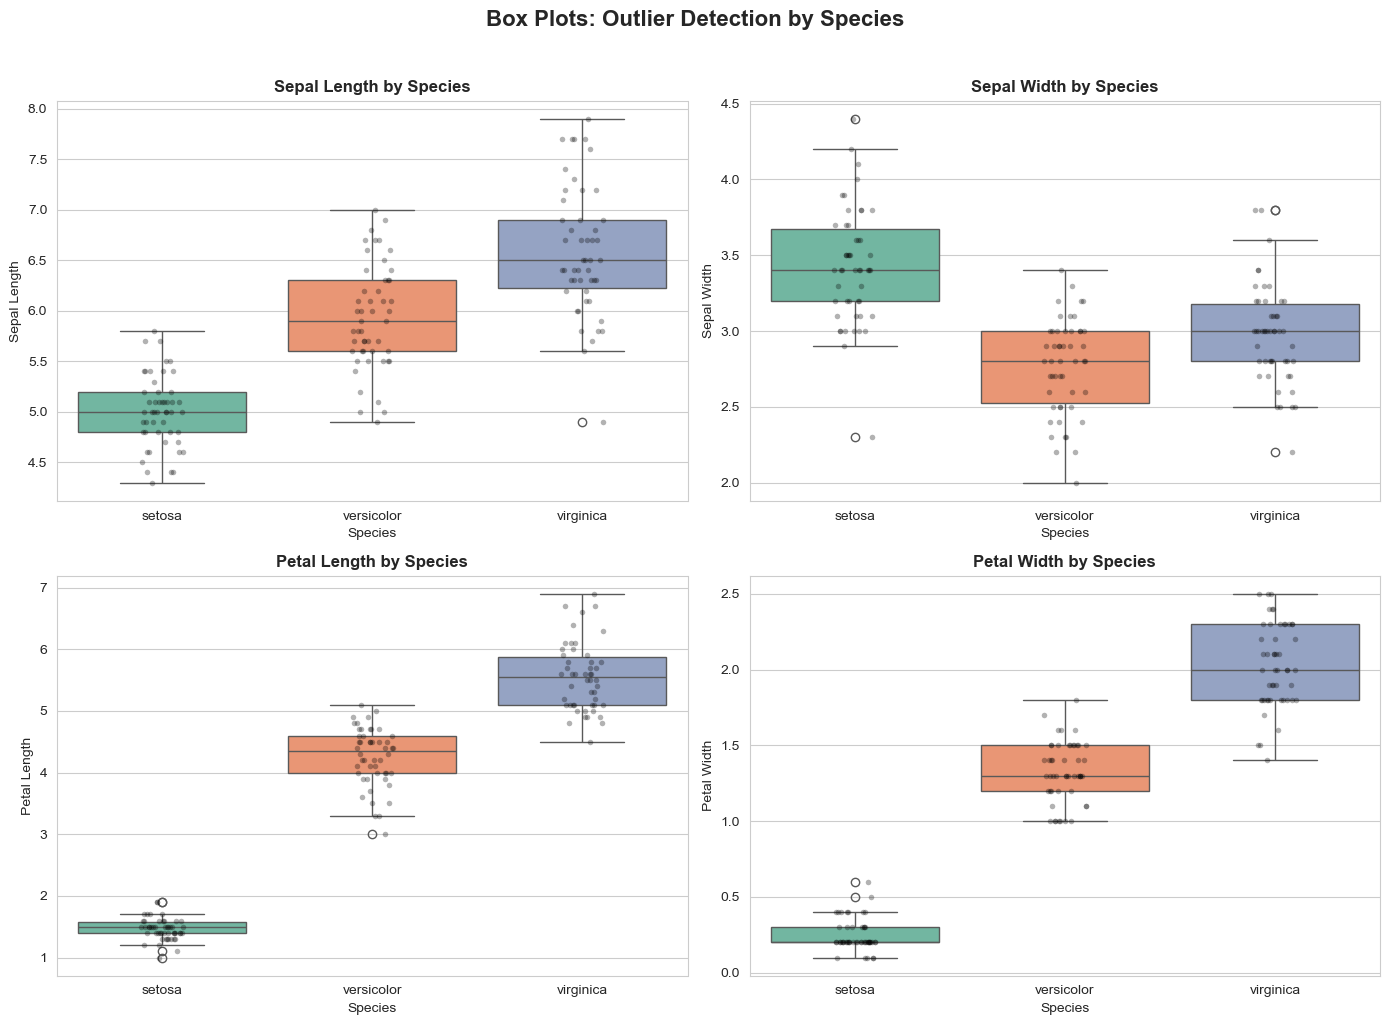

✓ Box plots saved!


In [7]:
# VISUALIZATION 4: Box Plots for Outlier Detection
fig4, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features):
    ax = axes[idx//2, idx%2]
    
    # Create box plot
    sns.boxplot(data=iris, x='species', y=feature, 
            hue='species', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{feature.replace("_", " ").title()} by Species', fontweight='bold')
    ax.set_xlabel('Species')
    ax.set_ylabel(feature.replace("_", " ").title())
    
    # Add individual points
    sns.stripplot(data=iris, x='species', y=feature, 
                  color='black', alpha=0.3, size=4, ax=ax)

plt.suptitle('Box Plots: Outlier Detection by Species', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/iris_BoxPlot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Box plots saved!")

In [8]:
# Summary of findings
print("\n" + "=" * 60)
print("SUMMARY OF FINDINGS")
print("=" * 60)

print("""
KEY INSIGHTS FROM IRIS DATASET EXPLORATION:

1. DATASET OVERVIEW:
   • 150 samples with 4 numerical features + 1 categorical target
   • No missing values - clean dataset
   • Balanced classes: 50 samples per species

2. FEATURE RELATIONSHIPS:
   • Petal length and petal width show strong positive correlation (~0.96)
   • Setosa is clearly separable from other species
   • Versicolor and Virginica show some overlap

3. DISTRIBUTIONS:
   • Sepal features show more overlap between species
   • Petal features show distinct distributions per species
   • Setosa has significantly smaller petals

4. OUTLIERS DETECTED:
   • Sepal width: Some outliers in versicolor and virginica
   • Overall, the dataset is well-behaved with minimal outliers

5. CORRELATIONS:
   • Strong positive: petal_length ↔ petal_width (0.96)
   • Moderate positive: sepal_length ↔ petal_length (0.87)
   • Weak negative: sepal_width ↔ petal_length (-0.43)
""")

print("\n✅ All visualizations have been generated and saved!")


SUMMARY OF FINDINGS

KEY INSIGHTS FROM IRIS DATASET EXPLORATION:

1. DATASET OVERVIEW:
   • 150 samples with 4 numerical features + 1 categorical target
   • No missing values - clean dataset
   • Balanced classes: 50 samples per species

2. FEATURE RELATIONSHIPS:
   • Petal length and petal width show strong positive correlation (~0.96)
   • Setosa is clearly separable from other species
   • Versicolor and Virginica show some overlap

3. DISTRIBUTIONS:
   • Sepal features show more overlap between species
   • Petal features show distinct distributions per species
   • Setosa has significantly smaller petals

4. OUTLIERS DETECTED:
   • Sepal width: Some outliers in versicolor and virginica
   • Overall, the dataset is well-behaved with minimal outliers

5. CORRELATIONS:
   • Strong positive: petal_length ↔ petal_width (0.96)
   • Moderate positive: sepal_length ↔ petal_length (0.87)
   • Weak negative: sepal_width ↔ petal_length (-0.43)


✅ All visualizations have been generated and

In [9]:
readme_content = """# Iris Dataset - Data Visualization Project

## Project Overview
Is project mein Iris dataset ka analysis kiya gaya hai.
150 flowers ki 4 features ko visualize kiya gaya hai.

## Dataset Information
- Total Rows: 150
- Total Columns: 5
- Species: Setosa, Versicolor, Virginica
- Source: Seaborn built-in dataset

## Libraries Used
- pandas
- matplotlib
- seaborn
- numpy
- os

## Visualizations Created
1. iris_pairplot.png     - Pairwise scatter plot matrix
2. iris_histogram.png    - Feature value distributions
3. iris_BoxPlot.png      - Outlier detection via box plots

## How to Run
1. Libraries install karo:
   pip install pandas matplotlib seaborn numpy

2. Jupyter Notebook kholo:
   jupyter notebook

3. Notebook open karo aur Run All karo

## Results
- Setosa species baaki donon se clearly alag hai
- Petal length aur petal width best features hain species ko identify karne ke liye
- Sepal width mein kuch outliers mojood hain
"""

# README.md file 
with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("✓ README.md successfully ban gayi!")
print(f"✓ Location: {os.getcwd()}\\README.md")

✓ README.md successfully ban gayi!
✓ Location: C:\Users\Dell\README.md


In [14]:
import os

# Check karo
if os.path.exists('README.md'):
    print("✅ README.md mil gayi!")
    print(f"📁 Location: {os.getcwd()}")
else:
    print("❌ File nahi bani")


✅ README.md mil gayi!
📁 Location: C:\Users\Dell
